# Air Quality & Weather Analysis in Turkey


## DS116: Data Visualization 
## Spring 2025
## American University of Armenia


<span style="font-size:20px">This project investigates air pollution trends across Turkey, exploring how different pollutants vary over time, region, and in relation to weather factors like temperature and precipitation.

### Import Required Libraries


In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors

# Mapping
import folium
from folium.plugins import MarkerCluster

# Interactive 
import plotly.express as px

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Style settings
sns.set(style='whitegrid')


ModuleNotFoundError: No module named 'folium'

### Step 1: Load and Clean Pollution Dataset

We clean the raw air pollution data by fixing date formats, splitting coordinates, converting types, and removing missing values.


In [ ]:
def load_and_clean_pollution_data():
    df = pd.read_csv('air_pollution.csv', sep=';')

    # Convert to datetime and remove time component
    df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')
    df = df.dropna(subset=['Last Updated'])
    df['Date'] = df['Last Updated'].dt.date

    # Extract coordinates
    df[['Latitude', 'Longitude']] = df['Coordinates'].str.split(',', expand=True)
    df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
    df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

    # Clean pollutant values
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

    # Standardize formatting
    df['City'] = df['City'].str.upper()
    df['Pollutant'] = df['Pollutant'].str.lower()

    # Drop invalid rows
    df = df.dropna(subset=['Value', 'Latitude', 'Longitude'])

    return df[['City', 'Pollutant', 'Value', 'Unit', 'Date', 'Latitude', 'Longitude']]

# Load the dataset
clean_pollution_df = load_and_clean_pollution_data()
clean_pollution_df.head()


,City,Pollutant,Value,Unit,Date,Latitude,Longitude
0,TOKAT,so2,3.139,µg/m³,2023-05-31,40.671785,36.561636
1,ANKARA,pm2.5,16.481,µg/m³,2023-05-31,39.953072,32.581754
2,KARABÜK,pm10,23.609,µg/m³,2023-05-31,41.197475,32.623379
3,İSTANBUL,o3,36.400,µg/m³,2023-05-31,41.002500,28.975278
4,İSTANBUL,co,826.063,µg/m³,2023-05-31,41.002500,28.975278


### Step 2: Most Frequently Measured Pollutants

We begin by analyzing which pollutants are most frequently recorded and which have the highest average concentrations across all cities and dates.


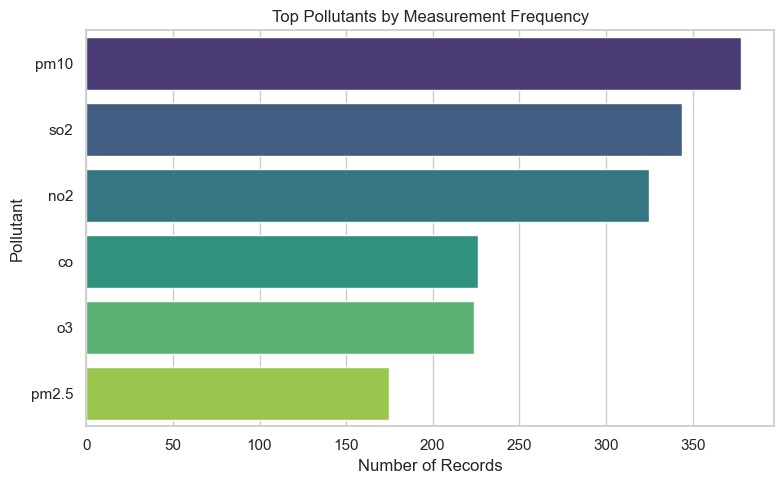

In [ ]:
#Top Pollutants by Frequency

def plot_pollutant_frequency(df, top_n=6):
    freq = df['Pollutant'].value_counts().head(top_n)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=freq.values, y=freq.index, palette='viridis')
    plt.title('Top Pollutants by Measurement Frequency')
    plt.xlabel('Number of Records')
    plt.ylabel('Pollutant')
    plt.tight_layout()
    plt.show()

plot_pollutant_frequency(clean_pollution_df)


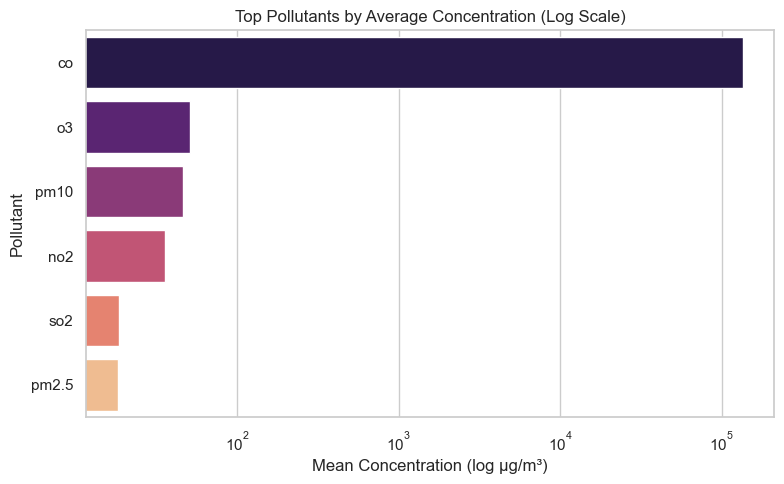

In [ ]:
#Top Pollutants by Average Concentration

def plot_pollutant_concentration(df, top_n=6):
    """
    Plot the top N pollutants by average concentration (log scale used to correct skew).
    """
    mean_vals = df.groupby('Pollutant')['Value'].mean().sort_values(ascending=False).head(top_n).reset_index()
    mean_vals.columns = ['Pollutant', 'Mean Concentration']

    plt.figure(figsize=(8, 5))
    sns.barplot(data=mean_vals, x='Mean Concentration', y='Pollutant', palette='magma', hue='Pollutant', legend=False)
    plt.xscale('log')  # Fix skew due to CO
    plt.title('Top Pollutants by Average Concentration (Log Scale)')
    plt.xlabel('Mean Concentration (log µg/m³)')
    plt.ylabel('Pollutant')
    plt.tight_layout()
    plt.show()

plot_pollutant_concentration(clean_pollution_df)


### Step 3: Daily Trends of Pollutants

We visualize daily average concentrations of each pollutant to uncover seasonal trends, spikes, or gradual shifts over time.


In [ ]:
def plot_pollutant_trend(df, pollutant_name):
    """
    Plot daily average concentration for a selected pollutant.
    """
    color_map = {
        'co': 'steelblue',
        'no2': 'darkorange',
        'o3': 'forestgreen',
        'pm10': 'crimson',
        'pm2.5': 'mediumorchid',
        'so2': 'saddlebrown'
    }

    df = df.copy()
    df['Pollutant'] = df['Pollutant'].str.lower()
    pollutant = pollutant_name.lower()

    # Filter
    subset = df[df['Pollutant'] == pollutant]
    if subset.empty:
        print(f"No data found for pollutant: {pollutant_name}")
        return

    # Daily average
    daily_avg = subset.groupby('Date')['Value'].mean().reset_index()

    plt.figure(figsize=(12, 4))
    sns.lineplot(data=daily_avg, x='Date', y='Value', color=color_map.get(pollutant, 'tab:blue'))
    plt.title(f'{pollutant_name.upper()} - Daily Average Concentration')
    plt.xlabel('Year')
    plt.ylabel('µg/m³')

    plt.grid(False)
    plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()


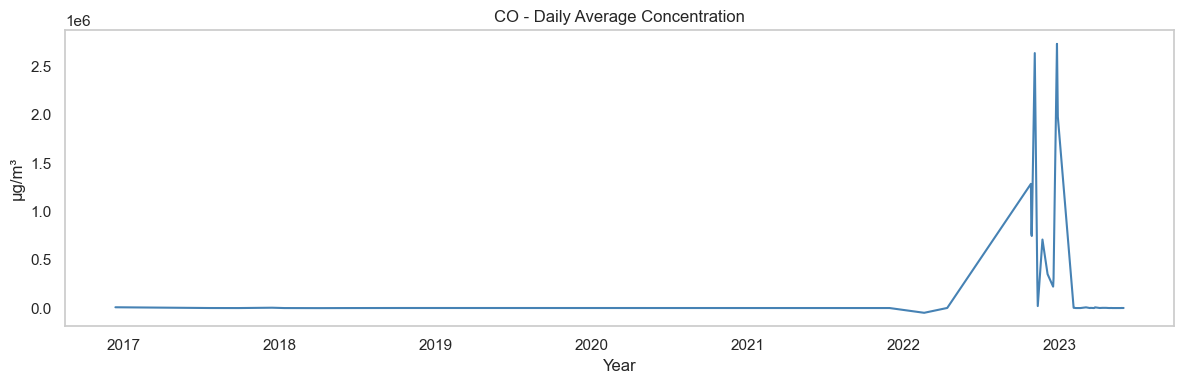

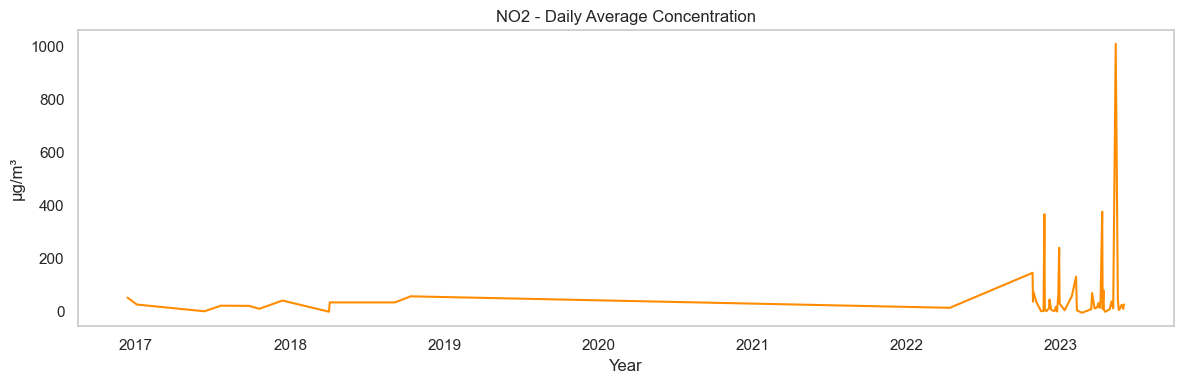

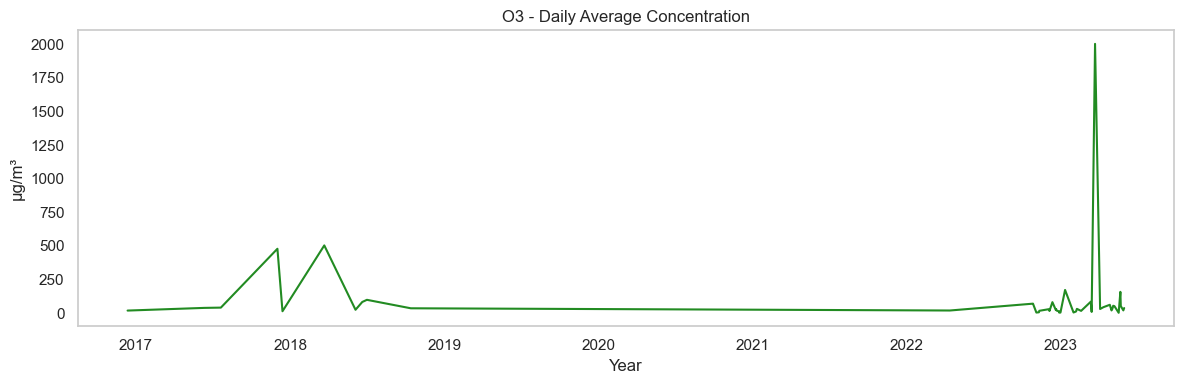

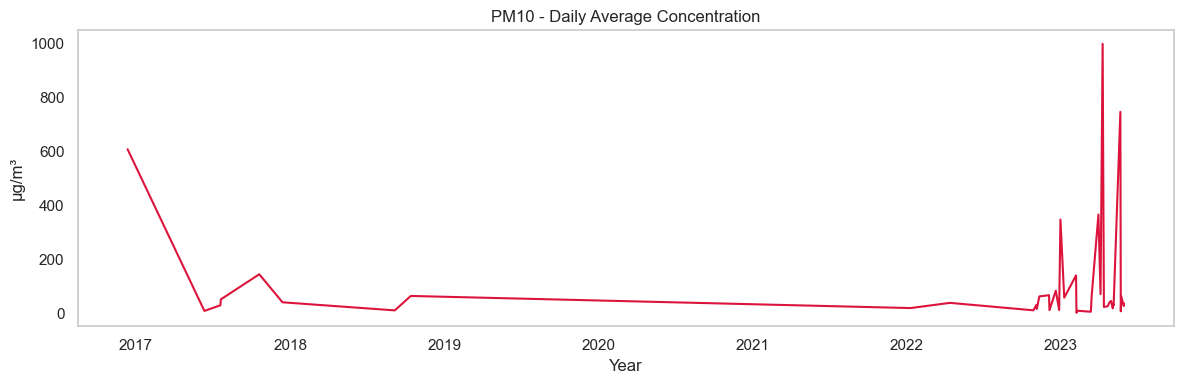

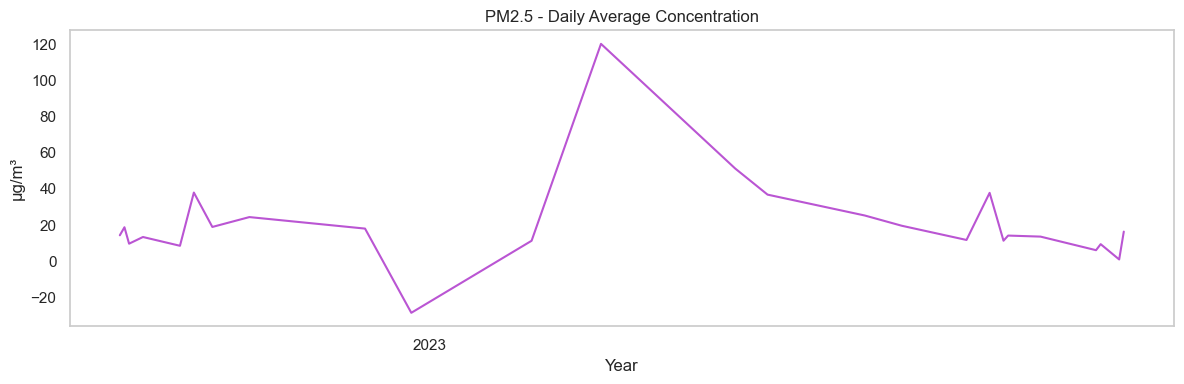

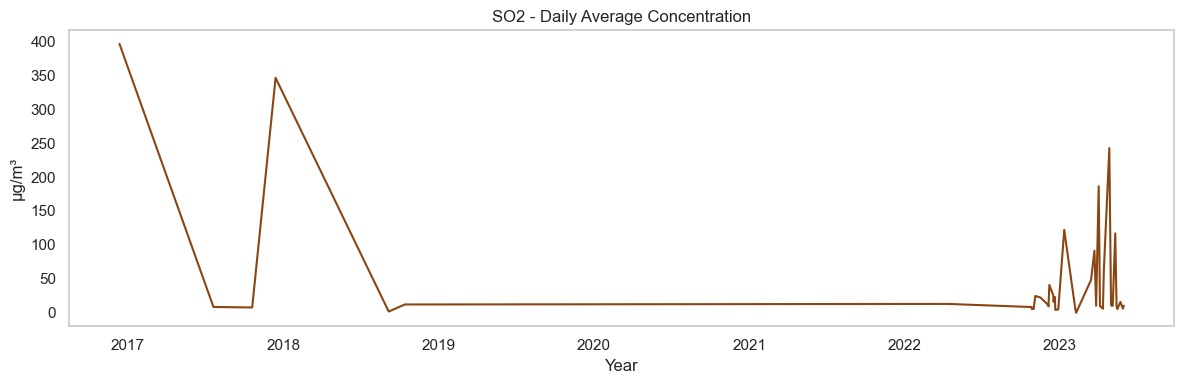

In [ ]:
plot_pollutant_trend(clean_pollution_df, 'CO')
plot_pollutant_trend(clean_pollution_df, 'NO2')
plot_pollutant_trend(clean_pollution_df, 'O3')
plot_pollutant_trend(clean_pollution_df, 'PM10')
plot_pollutant_trend(clean_pollution_df, 'PM2.5')
plot_pollutant_trend(clean_pollution_df, 'SO2')


### Step 4: Top Polluted Cities by Pollutant

We calculate and visualize the top 10 cities with the highest average concentration for each major pollutant. This helps us identify key pollution hotspots across Turkey.


In [ ]:
def plot_top_polluted_cities(df, pollutant_name, top_n=10):
    """
    Plot top N cities with highest average concentration for a given pollutant.
    """
    df = df.copy()
    df['Pollutant'] = df['Pollutant'].str.lower()
    pollutant = pollutant_name.lower()

    subset = df[df['Pollutant'] == pollutant]
    if subset.empty:
        print(f"No data for pollutant: {pollutant_name}")
        return

    city_avg = subset.groupby('City')['Value'].mean().sort_values(ascending=False).head(top_n).reset_index()
    city_avg.columns = ['City', 'Mean Concentration']

    plt.figure(figsize=(10, 5))
    sns.barplot(data=city_avg, x='Mean Concentration', y='City', palette='rocket', hue='City', legend=False)
    plt.title(f'Top {top_n} Cities by Average {pollutant_name.upper()} Concentration')
    plt.xlabel('Mean Concentration (µg/m³)')
    plt.ylabel('City')
    plt.tight_layout()
    plt.show()


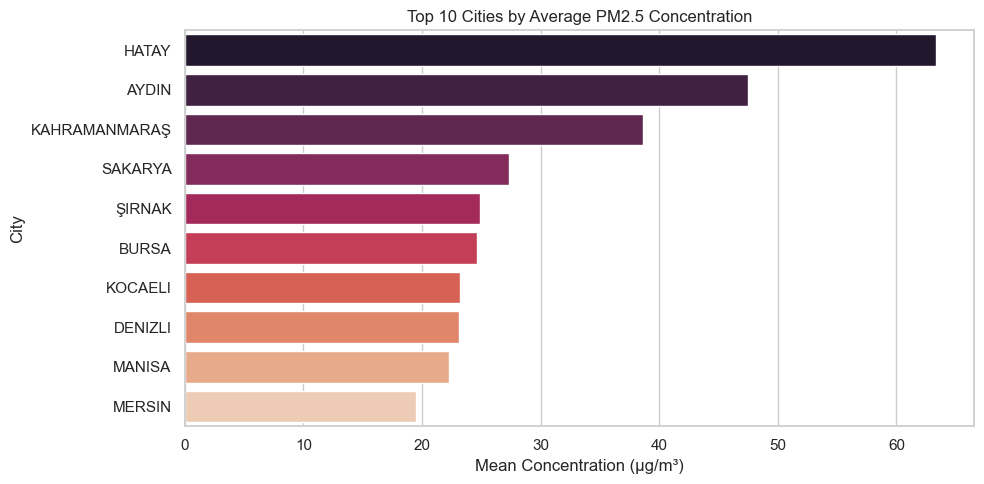

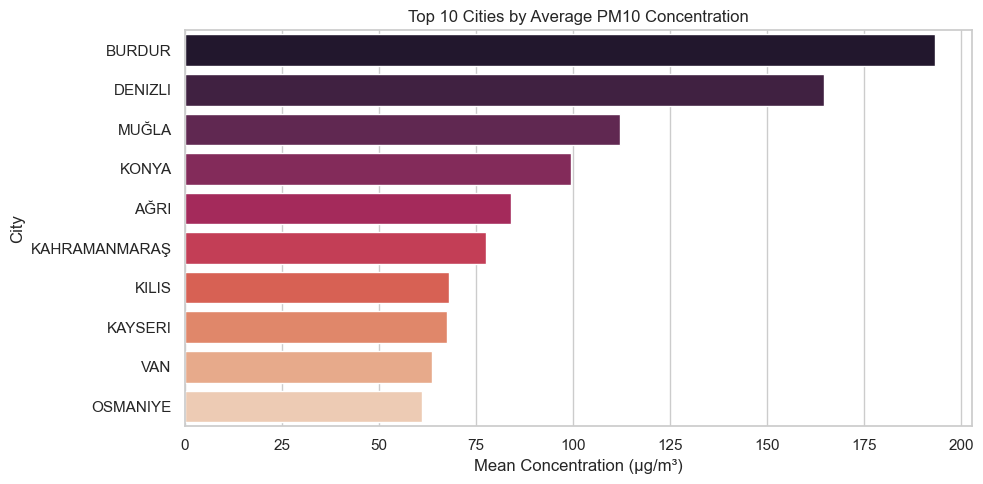

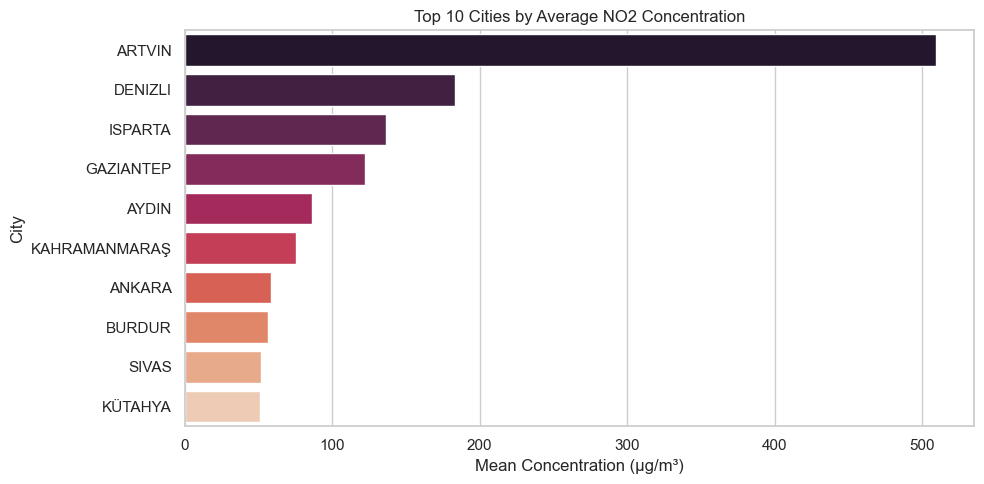

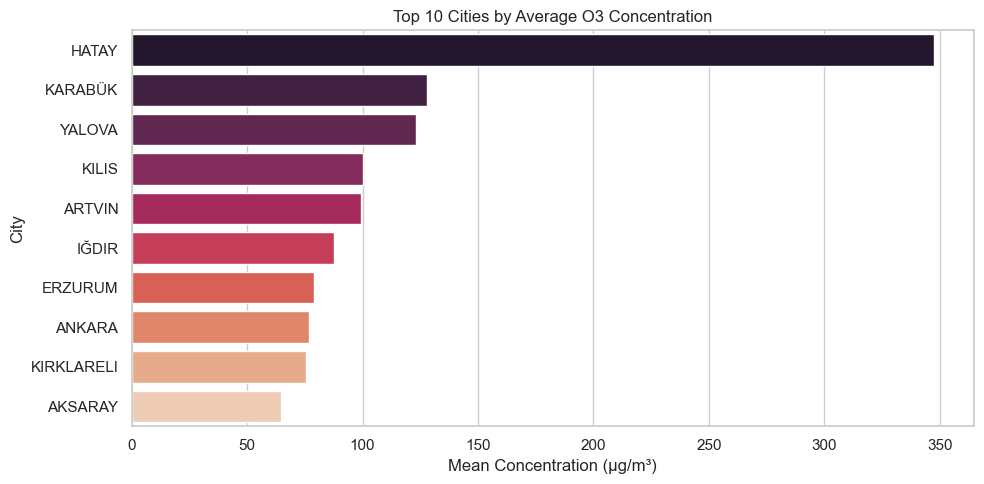

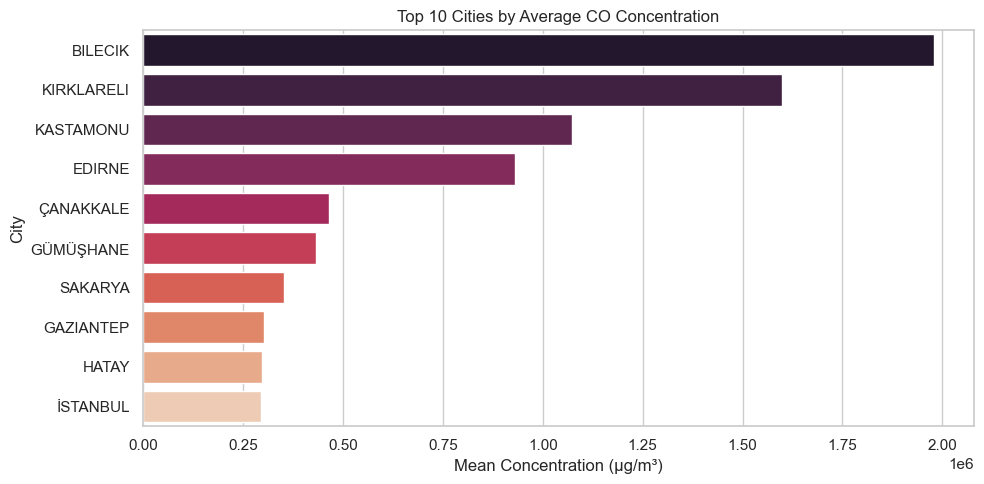

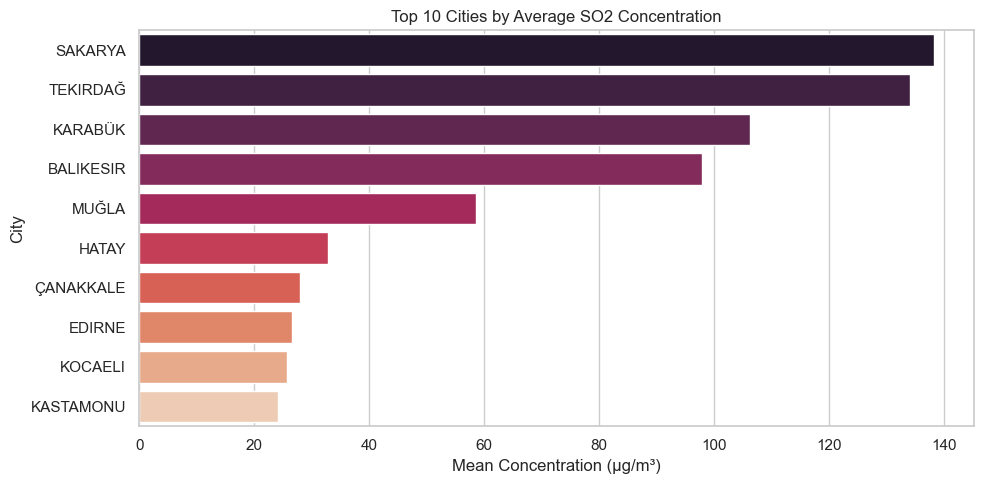

In [ ]:
plot_top_polluted_cities(clean_pollution_df, 'PM2.5')
plot_top_polluted_cities(clean_pollution_df, 'PM10')
plot_top_polluted_cities(clean_pollution_df, 'NO2')
plot_top_polluted_cities(clean_pollution_df, 'O3')
plot_top_polluted_cities(clean_pollution_df, 'CO')
plot_top_polluted_cities(clean_pollution_df, 'SO2')


### 5. Load and Transform Monthly Weather Data

This step loads average monthly temperature data and reshapes it into long format (one row per city-month combination). This allows merging with pollution data.


In [ ]:
def load_monthly_weather(filepath, value_column='Average Temperature'):
    """
    Load and reshape monthly weather data into long format with columns: City, Month, Value.
    """
    df = pd.read_csv(filepath)
    
    month_columns = [
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ]
    
    df_long = df.melt(
        id_vars='City',
        value_vars=month_columns,
        var_name='Month',
        value_name=value_column
    )
    
    return df_long

# Load temperature data
weather_avg_temp = load_monthly_weather('average_temp.csv', value_column='AvgTemp')
weather_avg_temp.head()


,City,Month,AvgTemp
0,ADANA,January,9.6
1,ADIYAMAN,January,4.8
2,AFYONKARAHISAR,January,0.4
3,AGRI,January,-10.6
4,AMASYA,January,2.8


### 6. Merge Pollution with Weather Data

We merge pollution and weather datasets by matching on City and Month, enabling analysis of how temperature affects pollution levels.


In [ ]:
def merge_pollution_with_weather(pollution_df, weather_df, weather_column='AvgTemp'):
    pollution_df = pollution_df.copy()
    pollution_df['Month'] = pd.to_datetime(pollution_df['Date']).dt.strftime('%B')
    
    pollution_df['City'] = pollution_df['City'].str.upper()
    weather_df['City'] = weather_df['City'].str.upper()

    merged_df = pd.merge(
        pollution_df,
        weather_df,
        how='left',
        on=['City', 'Month']
    )
    
    return merged_df

merged_pollution_weather = merge_pollution_with_weather(clean_pollution_df, weather_avg_temp, weather_column='AvgTemp')
merged_pollution_weather[['City', 'Date', 'Pollutant', 'Value', 'Month', 'AvgTemp']].head()


,City,Date,Pollutant,Value,Month,AvgTemp
0,TOKAT,2023-05-31,so2,3.139,May,16.4
1,ANKARA,2023-05-31,pm2.5,16.481,May,16.3
2,KARABÜK,2023-05-31,pm10,23.609,May,NaN
3,İSTANBUL,2023-05-31,o3,36.400,May,NaN
4,İSTANBUL,2023-05-31,co,826.063,May,NaN


### 7. Correlation Heatmap: Pollutants vs Temperature

We compute the correlation matrix between pollutants and average temperature to understand how weather conditions may influence air quality.


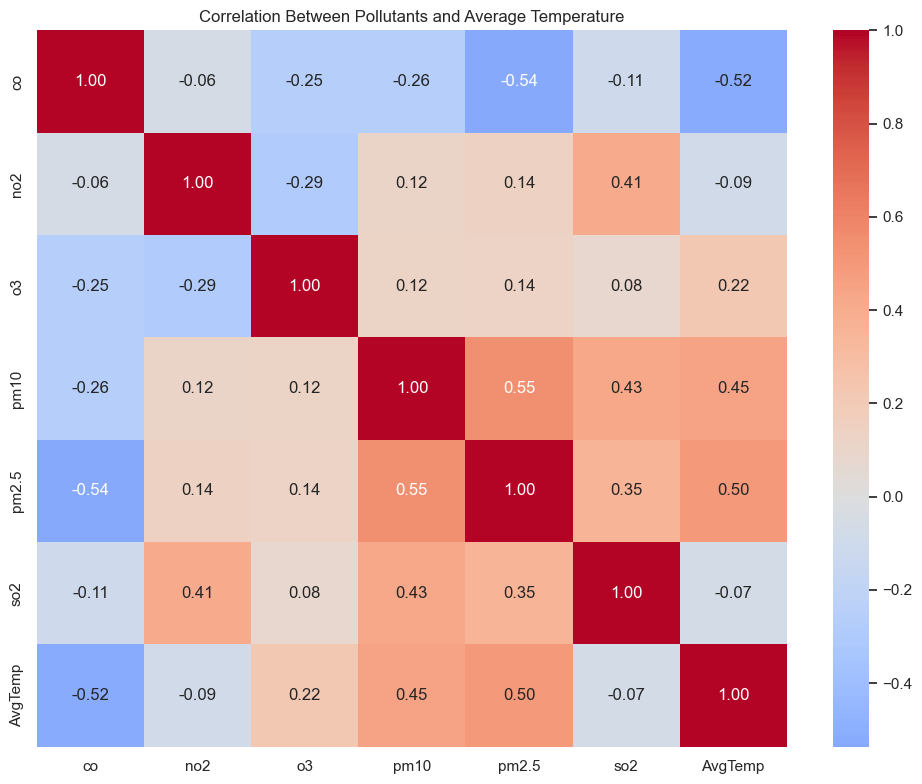

In [ ]:
def correlation_with_temperature_and_pollutants(df):
    df = df.copy()
    df['Pollutant'] = df['Pollutant'].str.lower()
    df = df.dropna(subset=['AvgTemp', 'Value'])

    pivot = df.pivot_table(index=['City', 'Date'], columns='Pollutant', values='Value', aggfunc='mean').reset_index()
    temp = df[['City', 'Date', 'AvgTemp']].drop_duplicates()
    full = pd.merge(pivot, temp, on=['City', 'Date'], how='left').dropna()

    corr_matrix = full.corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Between Pollutants and Average Temperature')
    plt.tight_layout()
    plt.show()

correlation_with_temperature_and_pollutants(merged_pollution_weather)


### 8. Pollution Intensity Heatmaps

Using folium and heatmap overlays, we visualize pollution hotspots in Turkey for each pollutant.


In [ ]:
# Load and clean pollution data for geospatial analysis
def load_pollution_data(path='air_pollution.csv'):
    df = pd.read_csv(path, sep=';')
    df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')
    df = df.dropna(subset=['Last Updated', 'Coordinates'])

    df[['Latitude', 'Longitude']] = df['Coordinates'].str.split(',', expand=True)
    df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
    df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    df['Pollutant'] = df['Pollutant'].str.lower()

    return df.dropna(subset=['Latitude', 'Longitude', 'Value'])

# Create a folium heatmap for a given pollutant
def create_heatmap(df, pollutant):
    sub_df = df[df['Pollutant'] == pollutant.lower()]
    heat_data = sub_df[['Latitude', 'Longitude', 'Value']].values.tolist()

    m = folium.Map(location=[39.0, 35.0], zoom_start=6, tiles='CartoDB positron')
    HeatMap(heat_data, radius=10, max_zoom=12).add_to(m)

    m.save(f"{pollutant}_pollution_heatmap.html")
    print(f"{pollutant.upper()} map saved as '{pollutant}_pollution_heatmap.html'")

df = load_pollution_data()
pollutants = ['pm2.5', 'pm10', 'no2', 'o3', 'so2', 'co']
for pollutant in pollutants:
    create_heatmap(df, pollutant)


PM2.5 map saved as 'pm2.5_pollution_heatmap.html'
PM10 map saved as 'pm10_pollution_heatmap.html'
NO2 map saved as 'no2_pollution_heatmap.html'
O3 map saved as 'o3_pollution_heatmap.html'
SO2 map saved as 'so2_pollution_heatmap.html'
CO map saved as 'co_pollution_heatmap.html'


### 9. Integrating Precipitation Data

To enhance the pollution analysis, we merge average monthly precipitation data with the pollution-weather dataset.


In [ ]:
# Load average monthly precipitation data
def load_monthly_precipitation(filepath='average_precipitation.csv', value_column='AvgPrecip'):
    df = pd.read_csv(filepath)

    # Melt wide format to long format
    month_columns = [
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ]
    df_long = df.melt(id_vars='City', value_vars=month_columns,
                      var_name='Month', value_name=value_column)

    # Clean formatting
    df_long['City'] = df_long['City'].str.upper()
    df_long['Month'] = df_long['Month'].str.strip().str.capitalize()

    return df_long

# Merge precipitation data into the pollution-weather dataset
def merge_precipitation(pollution_weather_df, precip_df, precip_col='AvgPrecip'):
    df = pollution_weather_df.copy()
    if precip_col in df.columns:
        df = df.drop(columns=[precip_col])  # remove any existing col

    df['City'] = df['City'].str.upper()
    df['Month'] = pd.to_datetime(df['Date']).dt.strftime('%B')
    precip_df['City'] = precip_df['City'].str.upper()
    precip_df['Month'] = precip_df['Month'].str.strip().str.capitalize()

    return pd.merge(df, precip_df, how='left', on=['City', 'Month'])

# Apply
precip_df = load_monthly_precipitation('average_precipitation.csv')
merged_pollution_weather = merge_precipitation(merged_pollution_weather, precip_df)


### 10. Interactive Map with Pollution, Temperature, and Precipitation

This map visualizes pollution values by city, enriched with temperature and precipitation context.


In [ ]:
def create_pollution_weather_map(df, pollutant='pm2.5', temp_col='AvgTemp', precip_col='AvgPrecip',
                                  output='pollution_weather_combined_map.html'):
    df = df[df['Pollutant'] == pollutant.lower()]
    df = df.dropna(subset=[temp_col, precip_col])

    city_data = df.groupby(['City', 'Latitude', 'Longitude'])[['Value', temp_col, precip_col]].mean().reset_index()
    m = folium.Map(location=[39.0, 35.0], zoom_start=6, tiles='CartoDB positron')

    for _, row in city_data.iterrows():
        color = 'green' if row['Value'] < 25 else 'orange' if row['Value'] < 50 else 'red'
        radius = 5 + (row[precip_col] / city_data[precip_col].max()) * 15

        popup = (
            f"<b>City:</b> {row['City']}<br>"
            f"<b>{pollutant.upper()}:</b> {row['Value']:.1f} µg/m³<br>"
            f"<b>Temperature:</b> {row[temp_col]:.1f} °C<br>"
            f"<b>Precipitation:</b> {row[precip_col]:.1f} mm"
        )

        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=radius,
            color=color,
            fill=True,
            fill_opacity=0.8,
            popup=folium.Popup(popup, max_width=300)
        ).add_to(m)

    m.save(output)
    print(f" Map saved as '{output}'")

# Run
create_pollution_weather_map(merged_pollution_weather)


 Map saved as 'pollution_weather_combined_map.html'


### 11. Pollution vs. Precipitation (Log-Scale Scatter Plot)

A scatterplot shows how average precipitation correlates with pollutant concentration across Turkish cities.


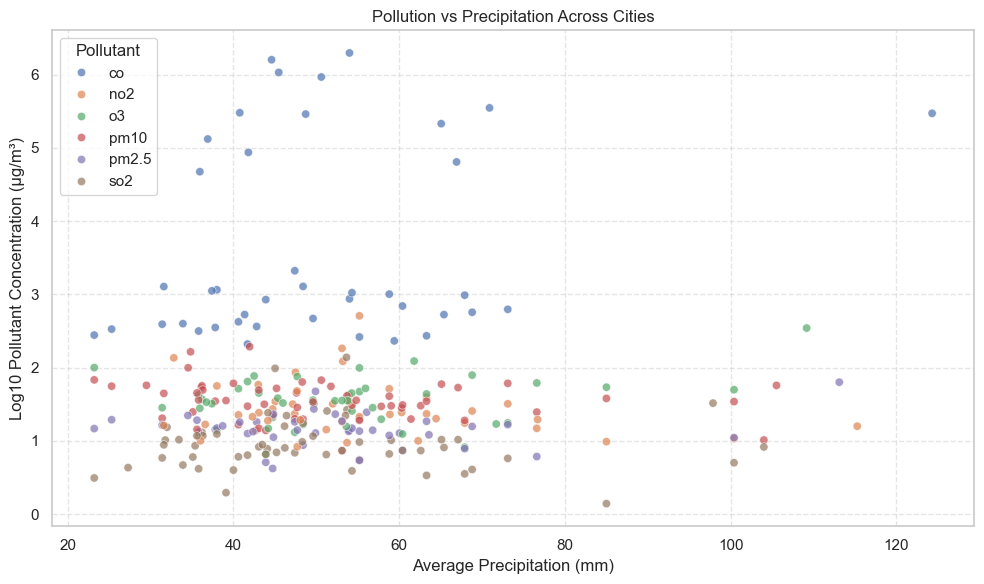

In [ ]:
# Prepare average pollutant vs precipitation data
precip_corr_df = merged_pollution_weather[['City', 'Pollutant', 'Value', 'AvgPrecip']].dropna()
city_pollutant_avg = precip_corr_df.groupby(['City', 'Pollutant']).agg({
    'Value': 'mean', 'AvgPrecip': 'mean'
}).reset_index()

city_pollutant_avg['LogValue'] = np.log10(city_pollutant_avg['Value'])

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=city_pollutant_avg, x='AvgPrecip', y='LogValue', hue='Pollutant', alpha=0.7)
plt.title('Pollution vs Precipitation Across Cities')
plt.xlabel('Average Precipitation (mm)')
plt.ylabel('Log10 Pollutant Concentration (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 12. Pollution vs. Temperature (Log-Scale Scatter Plot)

Here, we visualize the effect of temperature on pollutant levels, averaged per city.


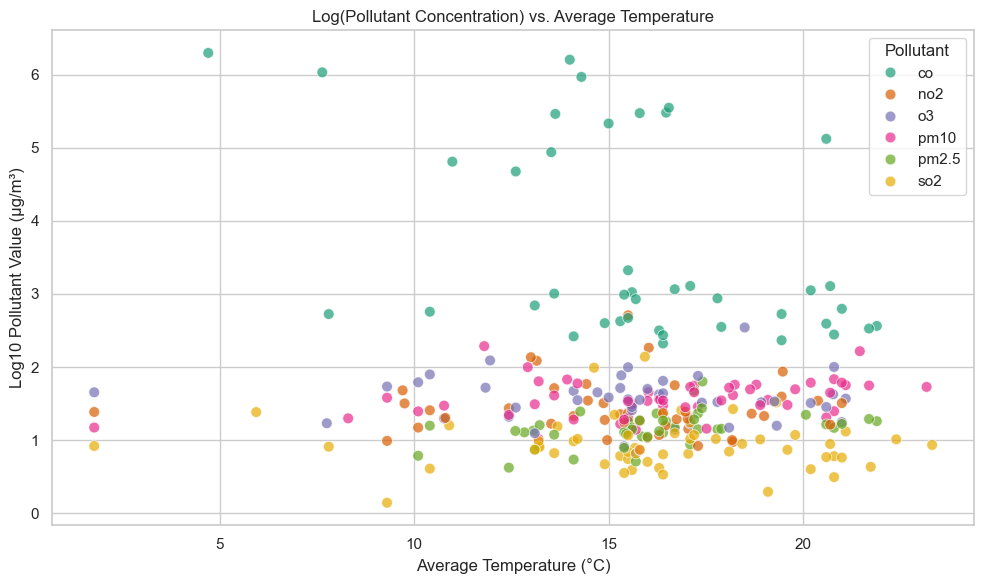

In [ ]:
filtered_df = merged_pollution_weather[['City', 'Pollutant', 'AvgTemp', 'Value']].dropna()
filtered_df['Pollutant'] = filtered_df['Pollutant'].str.lower()

city_pollutant_avg = (
    filtered_df.groupby(['City', 'Pollutant'])[['AvgTemp', 'Value']]
    .mean()
    .reset_index()
)

city_pollutant_avg = city_pollutant_avg[city_pollutant_avg['Value'] > 0].copy()
city_pollutant_avg['LogValue'] = np.log10(city_pollutant_avg['Value'])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=city_pollutant_avg,
    x='AvgTemp',
    y='LogValue',
    hue='Pollutant',
    palette='Dark2',
    alpha=0.7,
    s=60
)

plt.title('Log(Pollutant Concentration) vs. Average Temperature')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Log10 Pollutant Value (µg/m³)')
plt.grid(True)
plt.tight_layout()
plt.show()


### 13. Interactive Scatter Plot with Plotly (Temperature vs. Pollution)

This interactive scatter plot allows exploring how each pollutant correlates with average temperature.
Use the facet grid to switch between pollutants and view city-specific variations.


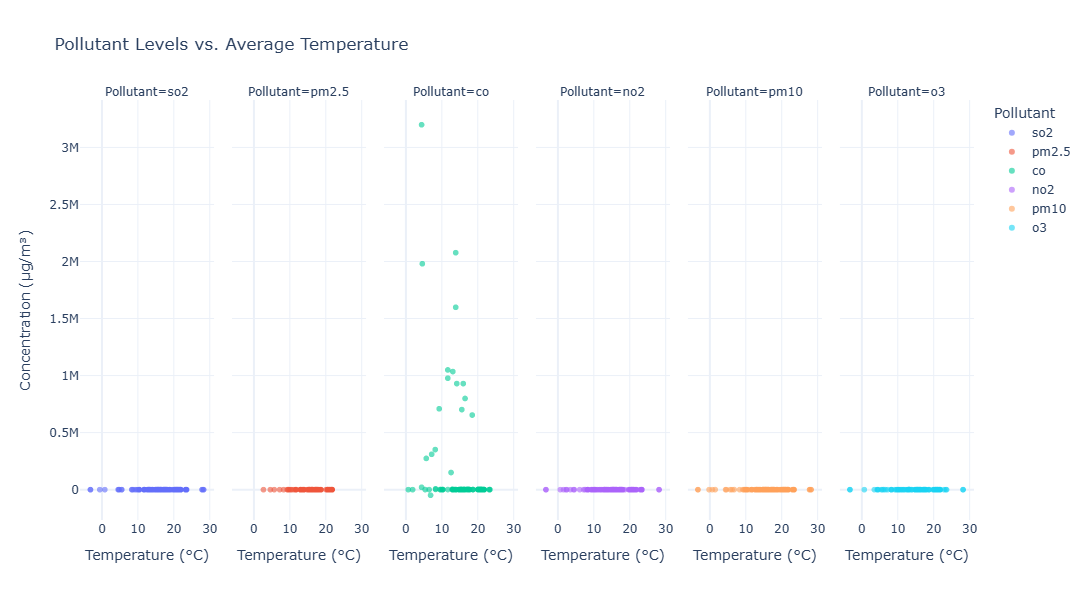

In [ ]:
# Prepare a merged dataset with complete values
plotly_df = merged_pollution_weather.copy()
plotly_df = plotly_df.dropna(subset=['AvgTemp', 'AvgPrecip', 'Value'])

# Ensure pollutant names are lowercase
plotly_df['Pollutant'] = plotly_df['Pollutant'].str.lower()

fig = px.scatter(
    plotly_df,
    x='AvgTemp',
    y='Value',
    color='Pollutant',
    facet_col='Pollutant',
    hover_data=['City', 'Date'],
    title='Pollutant Levels vs. Average Temperature',
    labels={'Value': 'Concentration (µg/m³)', 'AvgTemp': 'Temperature (°C)'},
    height=600
)

fig.update_traces(marker=dict(size=6, opacity=0.6))
fig.update_layout(template='plotly_white')
fig.show()


### 14. Interactive Hotspot Map for Pollution Levels

This map shows pollution hotspots by aggregating average pollutant concentrations for each city.
Marker color represents pollutant type, and size reflects pollution level.


In [ ]:
# Filter relevant pollution data
poll_map_df = (
    merged_pollution_weather
    .dropna(subset=['Latitude', 'Longitude', 'Value'])
    .copy()
)
poll_map_df['Pollutant'] = poll_map_df['Pollutant'].str.upper()

# Group by city and pollutant
avg_df = poll_map_df.groupby(['City', 'Pollutant', 'Latitude', 'Longitude'])[['Value']].mean().reset_index()

# Color palette per pollutant
pollutant_colors = {
    'PM2.5': 'crimson',
    'PM10': 'orange',
    'NO2': 'blue',
    'SO2': 'purple',
    'CO': 'darkred',
    'O3': 'green'
}

# Create map
hotspot_map = folium.Map(location=[39.0, 35.0], zoom_start=6)
marker_cluster = MarkerCluster().add_to(hotspot_map)

# Add markers
for _, row in avg_df.iterrows():
    pollutant = row['Pollutant']
    color = pollutant_colors.get(pollutant, 'gray')
    popup = f"""
    <b>City:</b> {row['City']}<br>
    <b>Pollutant:</b> {pollutant}<br>
    <b>Average Value:</b> {row['Value']:.1f} µg/m³
    """
    folium.CircleMarker(
        location=(row['Latitude'], row['Longitude']),
        radius=5 + (row['Value'] / avg_df['Value'].max()) * 10,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        popup=popup
    ).add_to(marker_cluster)

# Save the map
output_file = 'pollution_hotspot_map.html'
hotspot_map.save(output_file)
print(f" Pollution hotspot map saved as '{output_file}'")


 Pollution hotspot map saved as 'pollution_hotspot_map.html'
